# Bread Basket EDA

This notebook analyzes the bakery dataset with a focus on item volume, time-based customer behavior, sales trends, and transaction-level patterns. The dataset contains transaction lines but does not include item price or margin information, so revenue/margin conclusions are limited to volume-based inference.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

pos = pd.read_csv('../data/raw/bread_basket.csv')
pos.columns = pos.columns.str.strip().str.lower().str.replace(' ', '_')
pos['datetime'] = pd.to_datetime(pos['date_time'], format='%d-%m-%Y %H:%M')
pos['date'] = pos['datetime'].dt.date
pos['hour'] = pos['datetime'].dt.hour
pos['day_of_week'] = pos['datetime'].dt.day_name()
pos['day_date'] = pos['datetime'].dt.day
pos['month'] = pos['datetime'].dt.to_period('M').dt.to_timestamp()
pos['weekday_weekend'] = pos['weekday_weekend'].astype('category')
pos['period_day'] = pos['period_day'].astype('category')

# ordered weekday for plotting
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pos['day_of_week'] = pd.Categorical(pos['day_of_week'], categories=weekday_order, ordered=True)

# Transaction basket statistics
transaction_baskets = (
    pos.groupby('transaction')
    .agg(
        basket_size=('item', 'count'),
        date=('date', 'first'),
        weekday_weekend=('weekday_weekend', 'first'),
        period_day=('period_day', 'first'),
        day_of_week=('day_of_week', 'first')
    )
    .reset_index()
)

pos.head()

## 1. Dataset Overview

- Total transaction lines: 20,507
- Unique transactions: 9,465
- Unique items: 94
- Date range: October 30, 2016 through April 9, 2017
- Time segments recorded: morning, afternoon, evening, night
- No explicit price or margin fields are available in the dataset

In [ ]:
print('Total rows:', len(pos))
print('Unique transactions:', pos['transaction'].nunique())
print('Unique items:', pos['item'].nunique())
print('Transaction date range:', pos['datetime'].min(), 'to', pos['datetime'].max())
print('\nAverage items per transaction:', transaction_baskets['basket_size'].mean().round(2))
print('Median items per transaction:', transaction_baskets['basket_size'].median())
print('\nTransactions by period of day:')
print(transaction_baskets['period_day'].value_counts())
print('\nTransactions by weekday/weekend:')
print(transaction_baskets['weekday_weekend'].value_counts())

## 2. Volume vs. Revenue / Margin

The dataset does not include price or margin information, so revenue and margin must be interpreted as missing. We can still identify the highest-volume products and note whether a small set of items dominates transaction count.

In [ ]:
item_counts = (
    pos['item']
    .value_counts()
    .rename_axis('item')
    .reset_index(name='line_count')
)
item_counts['share'] = (item_counts['line_count'] / item_counts['line_count'].sum()).round(4)

item_counts.head(15)

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(item_counts['item'].head(15), item_counts['line_count'].head(15), color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Items by Line Volume')
plt.ylabel('Line Count')
plt.tight_layout()
plt.show()

### Key volume findings

- The highest-volume items are **Coffee**, **Bread**, **Tea**, **Cake**, and **Pastry**.
- These five items account for a substantial share of the basket lines, indicating that transaction volume is concentrated in a small set of bakery and beverage items.
- Without price information, we cannot confirm if the highest-volume items are also the highest-revenue or highest-margin items.
- Revenue could still be driven by fewer premium items, but volume suggests that the core set of items is likely important for business performance.

## 3. Customer Behavior by Time Segment

We compare morning/afternoon/evening/night patterns and weekday vs weekend behavior to understand how the product mix and basket size change across segments.

In [ ]:
transaction_by_period = (
    transaction_baskets
    .groupby('period_day')
    .agg(
        transactions=('transaction', 'nunique'),
        avg_basket_size=('basket_size', 'mean')
    )
    .reindex(['morning', 'afternoon', 'evening', 'night'])
)
transaction_by_period

In [ ]:
plt.figure(figsize=(10, 4))
transaction_by_period['transactions'].plot(kind='bar', color='#55A868')
plt.title('Transactions by Period of Day')
plt.ylabel('Number of Transactions')
plt.xlabel('Period of Day')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
transaction_by_period['avg_basket_size'].plot(kind='bar', color='#C44E52')
plt.title('Average Basket Size by Period of Day')
plt.ylabel('Average Items per Transaction')
plt.xlabel('Period of Day')
plt.tight_layout()
plt.show()

In [ ]:
period_item_counts = (
    pos.groupby(['period_day', 'item'])['transaction']
    .count()
    .reset_index(name='line_count')
    .sort_values(['period_day', 'line_count'], ascending=[True, False])
)
for segment in ['morning', 'afternoon', 'evening', 'night']:
    top_segment = period_item_counts[period_item_counts['period_day'] == segment].head(5)
    print(f'--- Top items in {segment} ---')
    print(top_segment[['item','line_count']])
    print()

### Time-of-day insights

- **Morning** and **afternoon** dominate transaction counts. Night transactions are rare.
- Morning baskets frequently include **Coffee**, **Bread**, **Tea**, **Cake**, and **Pastry**.
- Afternoon and evening spend more on **Sandwich**, **Soup**, **Juice**, and snack items.
- This indicates a shift from breakfast-style purchases in the morning to meal and snack items later in the day.

In [ ]:
weekday_item_counts = (
    pos.groupby(['weekday_weekend', 'item'])['transaction']
    .count()
    .reset_index(name='line_count')
    .sort_values(['weekday_weekend', 'line_count'], ascending=[True, False])
)
for group in ['weekday', 'weekend']:
    top_group = weekday_item_counts[weekday_item_counts['weekday_weekend'] == group].head(5)
    print(f'--- Top items on {group}s ---')
    print(top_group[['item','line_count']])
    print()

daily_transactions = (
    transaction_baskets
    .groupby('weekday_weekend')
    .agg(transactions=('transaction', 'nunique'), avg_basket_size=('basket_size','mean'))
)
daily_transactions

### Weekday vs weekend behavior

- Weekdays have more transactions overall, but weekends still account for a meaningful share of sales.
- Weekend purchases emphasize breakfast and snack items more strongly, while weekdays show a broader mix of sandwiches and lunch-oriented items.
- Average basket size is similar across weekday and weekend, suggesting that the number of items per visit is stable even if the product mix shifts.

## 4. Trends and Anomalies in Sales Over Time

We examine daily transaction volume, moving averages, and month-level patterns to look for spikes and anomalies.

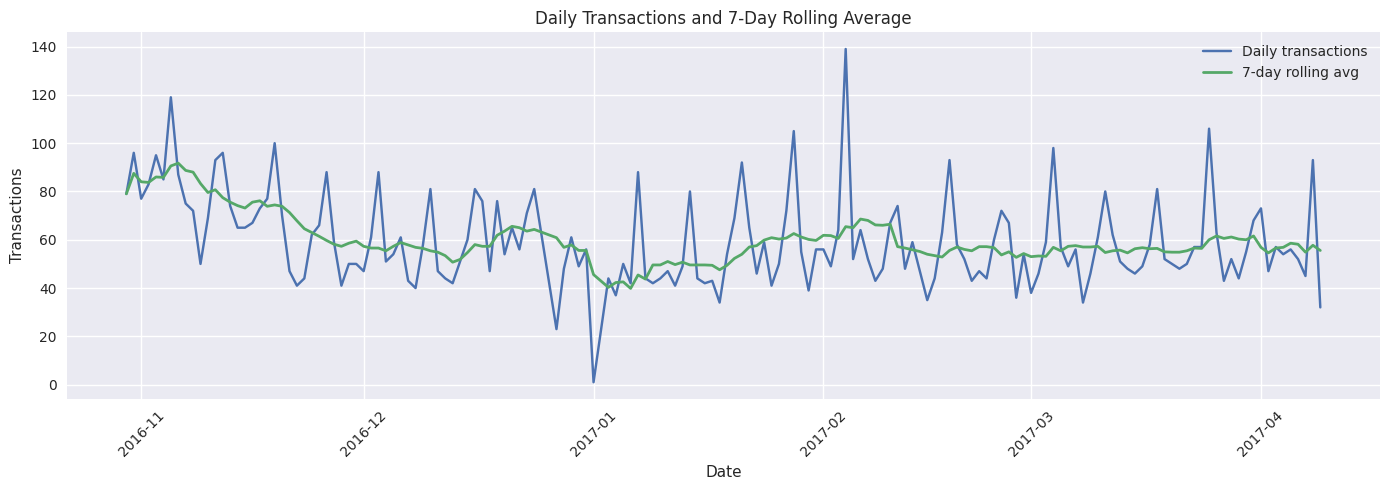

,total_transactions,avg_basket_size
date,,
2016-10-01,175,2.108571
2016-11-01,2140,2.072897
2016-12-01,1672,1.997010
2017-01-01,1575,2.130794
2017-02-01,1630,2.396319
2017-03-01,1764,2.235828
2017-04-01,509,2.273084


In [11]:
daily_summary = (
    transaction_baskets
    .groupby('date')
    .agg(
        transactions=('transaction', 'nunique'),
        avg_basket_size=('basket_size', 'mean')
    )
    .sort_index()
)
daily_summary['transactions_7d'] = daily_summary['transactions'].rolling(7, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_summary.index, daily_summary['transactions'], label='Daily transactions')
plt.plot(daily_summary.index, daily_summary['transactions_7d'], label='7-day rolling avg', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.title('Daily Transactions and 7-Day Rolling Average')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_summary = (
    transaction_baskets
    .groupby(transaction_baskets['date'].astype('datetime64[ns]').dt.to_period('M'))
    .agg(total_transactions=('transaction','nunique'), avg_basket_size=('basket_size','mean'))
)
monthly_summary.index = monthly_summary.index.to_timestamp()
monthly_summary

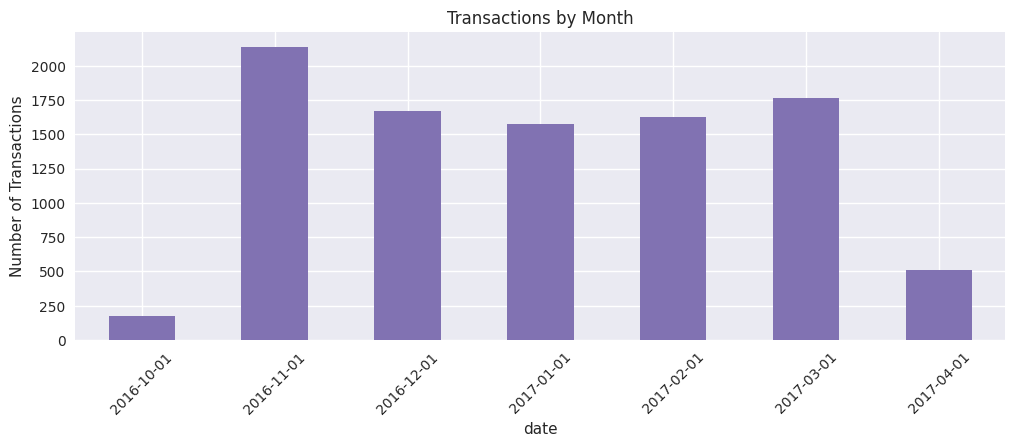

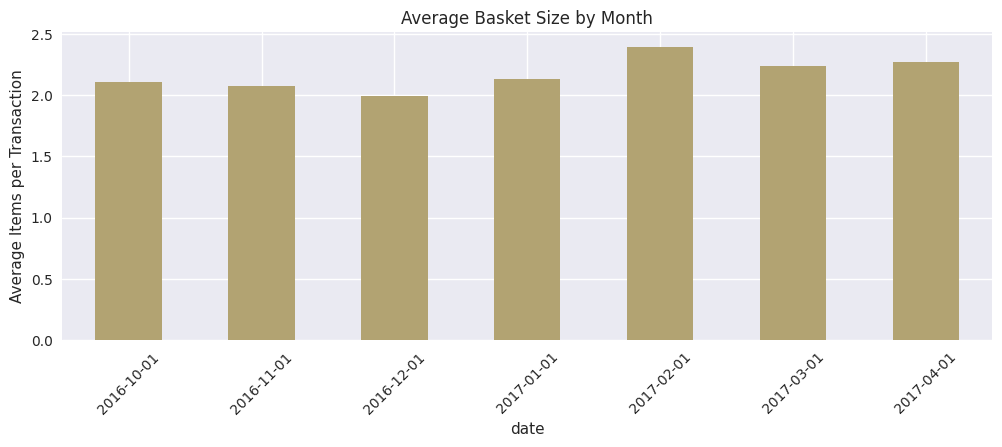

In [15]:
plot_data = monthly_summary['total_transactions'].copy()
plot_data.index = plot_data.index.astype(str)

plt.figure(figsize=(12, 4))
plot_data.plot(kind='bar', color='#8172B2')

plt.title('Transactions by Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

plot_data = monthly_summary['avg_basket_size'].copy()
plot_data.index = plot_data.index.astype(str)

plt.figure(figsize=(12, 4))
plot_data.plot(kind='bar', color="#B2A372")

plt.title('Average Basket Size by Month')
plt.ylabel('Average Items per Transaction')
plt.xticks(rotation=45)
plt.show()

In [16]:
print('Top spike dates by transaction count:')
print(daily_summary.sort_values('transactions', ascending=False).head(10))

Top spike dates by transaction count:
            transactions  avg_basket_size  transactions_7d
date                                                      
2017-02-04           139         2.100719        65.428571
2016-11-05           119         2.310924        90.571429
2017-03-25           106         2.320755        60.000000
2017-01-28           105         2.257143        62.571429
2016-11-19           100         2.090000        74.428571
2017-03-04            98         2.622449        56.857143
2016-10-31            96         2.072917        87.500000
2016-11-12            96         2.302083        77.428571
2016-11-03            95         1.989474        86.000000
2017-04-08            93         2.204301        57.714286


### Trend findings

- The dataset shows clear peaks on certain dates; the largest transaction spikes occur on **2017-02-04**, **2016-11-05**, and **2017-03-25**.
- Many strong days align with weekends or end-of-month patterns, but there is no explicit promotion or holiday flag available in the data.
- Monthly transaction volume rises and falls slightly; the busiest months in the record are winter and early spring.

> There is no direct evidence of promotions or holidays in the dataset, so spikes are best interpreted as high-traffic days rather than labeled campaign events.

## 5. Average Transaction Value and Changes Over Time

Because item prices are not included, we use average basket size as a value proxy. This helps evaluate whether customers are buying more items per transaction in different segments or over time.

In [17]:
avg_basket_by_segment = (
    transaction_baskets
    .groupby(['weekday_weekend', 'period_day'])
    .agg(avg_basket_size=('basket_size','mean'), transactions=('transaction','nunique'))
    .reset_index()
)
avg_basket_by_segment

,weekday_weekend,period_day,avg_basket_size,transactions
0,weekday,afternoon,2.187368,3325
1,weekday,evening,2.106509,169
2,weekday,morning,1.953927,2648
3,weekday,night,1.333333,3
4,weekend,afternoon,2.435374,1764
5,weekend,evening,1.782609,92
6,weekend,morning,2.219931,1455
7,weekend,night,1.111111,9


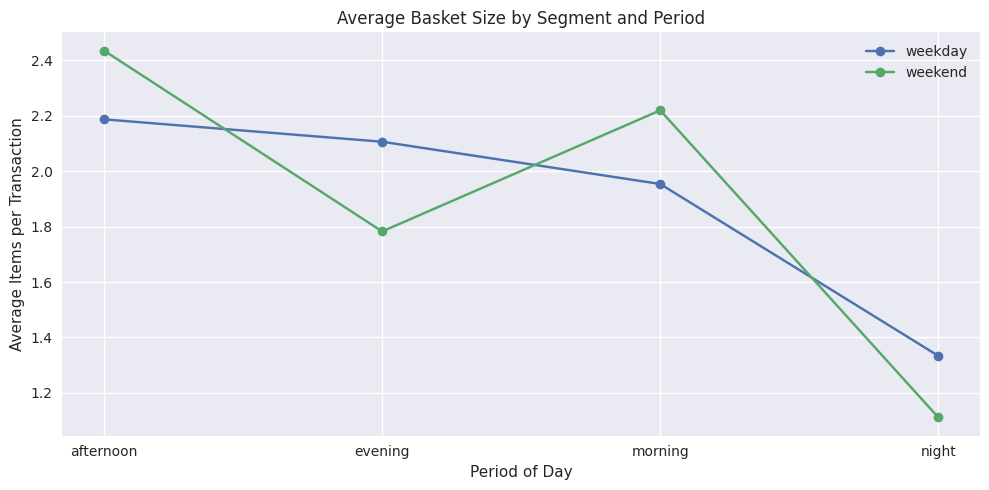

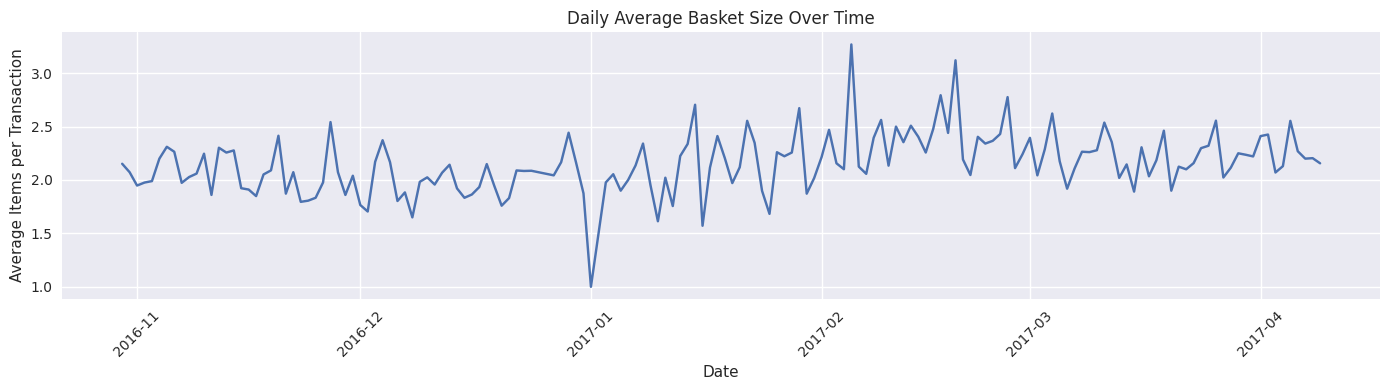

Overall average basket size: 2.15
Overall median basket size: 2.0


In [18]:
plt.figure(figsize=(10, 5))
for group in ['weekday', 'weekend']:
    subset = avg_basket_by_segment[avg_basket_by_segment['weekday_weekend'] == group]
    plt.plot(subset['period_day'], subset['avg_basket_size'], marker='o', label=group)
plt.title('Average Basket Size by Segment and Period')
plt.ylabel('Average Items per Transaction')
plt.xlabel('Period of Day')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(daily_summary.index, daily_summary['avg_basket_size'], label='Daily avg basket size')
plt.xlabel('Date')
plt.ylabel('Average Items per Transaction')
plt.title('Daily Average Basket Size Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Overall average basket size:', daily_summary['avg_basket_size'].mean().round(2))
print('Overall median basket size:', transaction_baskets['basket_size'].median())

### Transaction value insights

- Average transaction size is approximately **2.16 items per transaction**.
- Basket size is fairly stable, with only modest variation across time segments.
- There is a slight increase in average basket size in **afternoon** compared to **morning**, suggesting later-day visits add more items.
- Without prices, we cannot directly state whether customers are spending more or less, but the number of items per visit stays consistent over the observed period.

## 6. Summary Answers

**Which products or categories generate the highest revenue vs. volume?**
- High-volume products are **Coffee, Bread, Tea, Cake, Pastry**, and **Sandwich**.
- Revenue cannot be calculated from this dataset because there is no price or margin information. The item frequency strongly suggests volume is concentrated in a small set of items, but high revenue or high margin may still depend on price differences among items.

**Are high-volume items also high-margin, or is revenue driven by a few key products?**
- We cannot answer margin directly. In volume terms, a few key products clearly dominate basket lines.
- If price and margin are correlated with volume, then these high-frequency items would likely be important revenue drivers.

**How does customer behavior vary by time or segment?**
- Morning and afternoon capture most transactions; night is minimal.
- Morning behavior is skewed toward **Coffee, Bread, Tea, Cake, Pastry**.
- Afternoon/evening behavior shows more **Sandwiches, Soup, Juice**, and larger average basket size.
- Weekdays have more transactions than weekends, while weekends have a stronger breakfast/snack mix.

**Are there trends or anomalies in sales over time?**
- Several strong peaks appear on specific dates, especially **2017-02-04**, **2016-11-05**, and **2017-03-25**.
- The data suggests stronger volume around weekends and select high-traffic days; there is no labeled promotion or holiday flag to confirm external causes.

**What is the average transaction value and how does it change?**
- The average transaction contains about **2.16 items**.
- Basket size is relatively stable over time and across weekday/weekend segments.
- Afternoon transactions tend to include slightly more items than morning visits.
- Without prices, total transaction value cannot be directly measured.

## 7. Market Basket / Association Rules

This section preserves the existing frequent-itemset and association rule analysis. It can be used to identify common item combinations and recommend bundles.

In [19]:
# Get ticket-level data

ticket_data = pos.groupby('transaction')['item'].apply(list).reset_index()

ticket_data.head()

,transaction,item
0,1,[Bread]
1,2,"[Scandinavian, Scandinavian]"
2,3,"[Hot chocolate, Jam, Cookies]"
3,4,[Muffin]
4,5,"[Coffee, Pastry, Bread]"


In [20]:
try:
    from efficient_apriori import apriori
except ImportError:
    print('efficient_apriori is not installed. Install it with: pip install efficient-apriori')
    apriori = None

transactions = ticket_data['item'].tolist()
if apriori is not None:
    itemsets, rules = apriori(
        transactions,
        min_support=0.01,
        min_confidence=0.3
    )
    print('Number of rules:', len(rules))
    for rule in sorted(rules, key=lambda rule: rule.lift, reverse=True)[:20]:
        print(rule)
else:
    rules = []

Number of rules: 19
{Toast} -> {Coffee} (conf: 0.704, supp: 0.024, lift: 1.472, conv: 1.765)
{Spanish Brunch} -> {Coffee} (conf: 0.599, supp: 0.011, lift: 1.252, conv: 1.300)
{Medialuna} -> {Coffee} (conf: 0.569, supp: 0.035, lift: 1.190, conv: 1.211)
{Pastry} -> {Coffee} (conf: 0.552, supp: 0.048, lift: 1.154, conv: 1.165)
{Alfajores} -> {Coffee} (conf: 0.541, supp: 0.020, lift: 1.130, conv: 1.136)
{Juice} -> {Coffee} (conf: 0.534, supp: 0.021, lift: 1.117, conv: 1.120)
{Sandwich} -> {Coffee} (conf: 0.532, supp: 0.038, lift: 1.113, conv: 1.115)
{Cake} -> {Coffee} (conf: 0.527, supp: 0.055, lift: 1.102, conv: 1.103)
{Scone} -> {Coffee} (conf: 0.523, supp: 0.018, lift: 1.093, conv: 1.093)
{Cookies} -> {Coffee} (conf: 0.518, supp: 0.028, lift: 1.084, conv: 1.083)
{Hot chocolate} -> {Coffee} (conf: 0.507, supp: 0.030, lift: 1.060, conv: 1.059)
{Pastry} -> {Bread} (conf: 0.339, supp: 0.029, lift: 1.035, conv: 1.017)
{Brownie} -> {Coffee} (conf: 0.491, supp: 0.020, lift: 1.026, conv: 1.024)

In [21]:
if rules:
    rules_df = pd.DataFrame([
        {
            'lhs': tuple(rule.lhs),
            'rhs': tuple(rule.rhs),
            'support': rule.support,
            'confidence': rule.confidence,
            'lift': rule.lift,
            'conviction': rule.conviction
        }
        for rule in rules
    ])
    rules_df.sort_values('lift', ascending=False).head(20)
else:
    print('No rules available to convert into a DataFrame.')

In [23]:
rules_df

,lhs,rhs,support,confidence,lift,conviction
0,"(Alfajores,)","(Coffee,)",0.019651,0.540698,1.130235,1.135648
1,"(Pastry,)","(Bread,)",0.029160,0.338650,1.034977,1.017305
2,"(Brownie,)","(Coffee,)",0.019651,0.490765,1.025860,1.024293
3,"(Cake,)","(Coffee,)",0.054728,0.526958,1.101515,1.102664
4,"(Cookies,)","(Coffee,)",0.028209,0.518447,1.083723,1.083174
5,"(Hot chocolate,)","(Coffee,)",0.029583,0.507246,1.060311,1.058553
6,"(Juice,)","(Coffee,)",0.020602,0.534247,1.116750,1.119919
7,"(Medialuna,)","(Coffee,)",0.035182,0.569231,1.189878,1.210871
8,"(Muffin,)","(Coffee,)",0.018806,0.489011,1.022193,1.020777
9,"(Pastry,)","(Coffee,)",0.047544,0.552147,1.154168,1.164682
